# 2. Weather and trends

This notebook takes out what the weather explains from each site's biomass, then fits a trend to what remains, at every site and for the country.

- **Reads** `site_year.csv` and `flags.csv` from `data/processed/` (notebook 1), and summer temperature from the release.
- **Writes** `remainders.csv` and `site_trends.csv` to `data/processed/`.

Everything is in log10 units. A trend of v log10 per decade means biomass, relative to the weather, changed by a factor of 10^v per decade, so −0.3 is a halving.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

from mn_desertification import data, paths, quality, trends
from mn_desertification.rules import ALPHA, FLOOR, MAIN_YEARS, ZONES
from mn_desertification.weather import fit_weather_model

MAP_ASPECT = 1 / np.cos(np.radians(47))

## The analysis table

The main period is 2011–2020, the years of NAMEM's standard method. Values below 0.1 c/ha are raised to 0.1 before taking logs, and the three flagged values are left out ([design](../docs/design.md)).

In [2]:
site_year = pd.read_csv(paths.PROCESSED_DIR / "site_year.csv")
flags = pd.read_csv(paths.PROCESSED_DIR / "flags.csv")
weather = data.read_soum_weather()

main = site_year[site_year["year"].between(*MAIN_YEARS)]
main = quality.drop_flagged(main, flags).copy()
main["bms_floored"] = main["bms"].clip(lower=FLOOR)
main = main.merge(weather[["asid", "year", "temp_summer"]], on=["asid", "year"], how="left")

print("Site-years:", len(main), "| sites:", main["gid"].nunique())
print("Without temperature:", main["temp_summer"].isna().sum())

Site-years: 13367 | sites: 1485
Without temperature: 0


## The weather model

Within each ecological zone,

> log10(biomass) = the site's own average + b × log10(growing-season rain) + remainder

The site's own average absorbs the fact that sites differ. The slope b is shared by all sites in a zone: with only ten years, a site's own fit would partly absorb the decline the study looks for, a weakness of residual trend analysis that Wessels et al. (2012) describe. There is no effect for each year, which would absorb any decline shared by the whole country.

The remainder is what the weather leaves unexplained, and the trends below are fitted to it. Rain only was the planned model.

In [3]:
rain_fit = fit_weather_model(main, "bms_floored", with_temp=False)
rain_fit.effects.set_index("zone").reindex(ZONES).round(3)

,b_rain,R2,site-years
zone,,,
Desert zone,1.118,0.120,951
Semi desert steppe zone,1.159,0.103,2810
Steppe zone,1.247,0.100,5763
Forest steppe zone,1.073,0.052,3402
Mountain taiga belt,1.205,0.046,441


Rain matters in every zone. b is 1.07 to 1.25, so biomass rises a little faster than rain: with b = 1.2, 10% more rain gives about 12% more biomass. But rain on the soum's summer range explains only 5 to 12% (R2) of a site's ups and downs. Most of the variation stays in the remainders, as measurement noise, local conditions and real change.

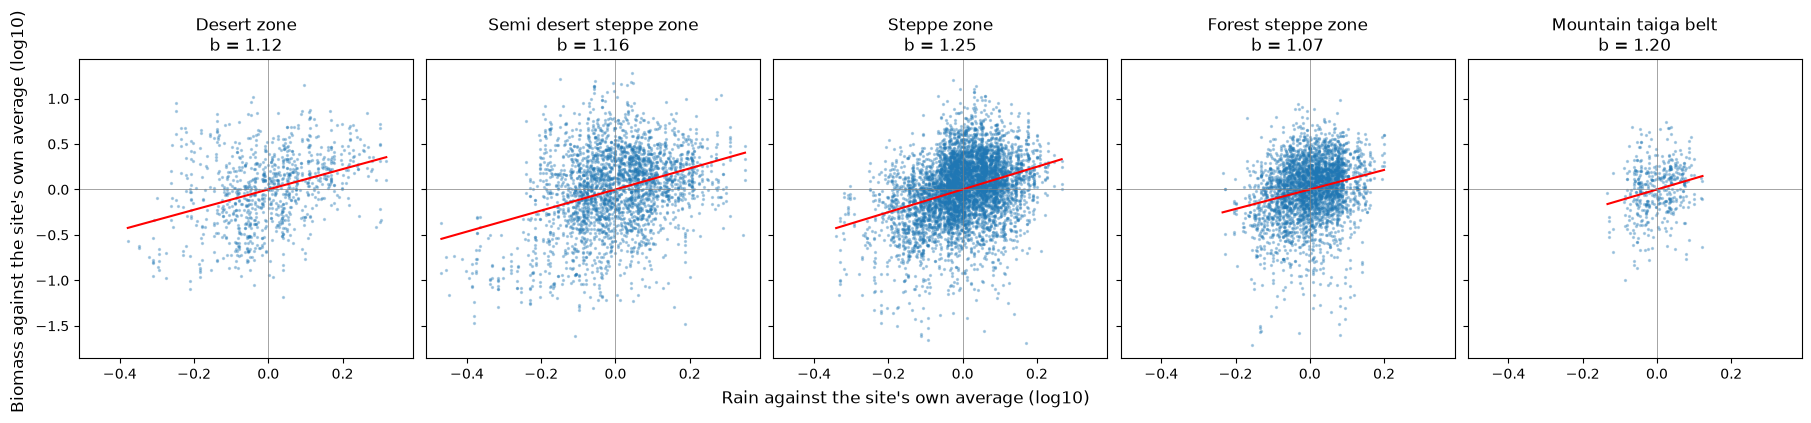

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=True, sharey=True, layout="constrained")
effects = rain_fit.effects.set_index("zone")
for ax, zone in zip(axes, ZONES):
    group = rain_fit.remainders[rain_fit.remainders["zone"] == zone]
    ax.scatter(group["rain"], group["y"], s=2, alpha=0.3)
    b = effects.loc[zone, "b_rain"]
    ends = np.array([group["rain"].min(), group["rain"].max()])
    ax.plot(ends, b * ends, color="red")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)
    ax.set_title(f"{zone}\nb = {b:.2f}")
fig.supxlabel("Rain against the site's own average (log10)")
fig.supylabel("Biomass against the site's own average (log10)")
plt.show()

### Adding summer temperature

The site trends below showed a pattern shared by the whole country, so summer temperature was added as a second model after they were first fitted. Both models are reported throughout.

> log10(biomass) = the site's own average + b × log10(rain) + c × summer temperature (°C) + remainder

In [5]:
temp_fit = fit_weather_model(main, "bms_floored", with_temp=True)
temp_effects = temp_fit.effects.set_index("zone").reindex(ZONES)
temp_effects["% per °C"] = trends.percent_per_decade(temp_effects["c_temp"]).round(1)
temp_effects.round(3)

,b_rain,c_temp,R2,site-years,% per °C
zone,,,,,
Desert zone,1.040,-0.109,0.148,951,-22.2
Semi desert steppe zone,0.834,-0.153,0.150,2810,-29.6
Steppe zone,0.765,-0.109,0.139,5763,-22.2
Forest steppe zone,0.697,-0.078,0.075,3402,-16.5
Mountain taiga belt,0.986,-0.098,0.094,441,-20.2


A warmer summer lowers biomass in every zone, by 0.08 to 0.15 log10 per degree, or about 17 to 30% less biomass. With temperature the model explains 8 to 15% of a site's ups and downs, and rain's own effect drops to 0.70–1.04, because dry summers are also hot.

## What the weather leaves unexplained, all sites

The mean remainder of all sites in each year, for both models, and the trend through those yearly means with its 95% range.

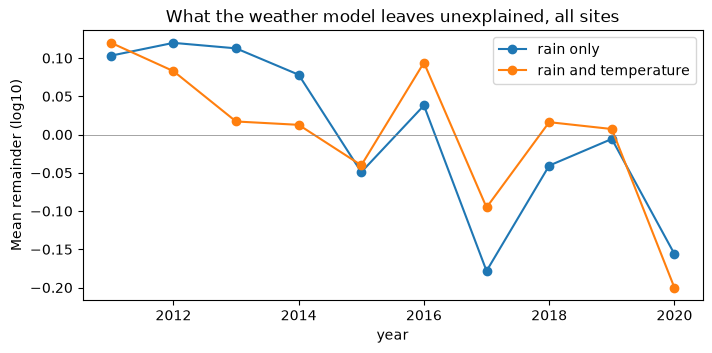

rain only: -0.283 log10 per decade (-48%), 95% range -0.461 to -0.104
rain and temperature: -0.219 log10 per decade (-40%), 95% range -0.403 to -0.034


year,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
rain only,0.103,0.120,0.113,0.078,-0.049,0.038,-0.178,-0.041,-0.006,-0.156
rain and temperature,0.120,0.083,0.017,0.013,-0.040,0.094,-0.095,0.016,0.007,-0.200


In [6]:
remainders = rain_fit.remainders[["gid", "year", "lon", "lat", "asid", "aimag_eng", "soum_eng", "zone", "bms"]].copy()
remainders["remainder_rain"] = rain_fit.remainders["remainder"]
remainders["remainder_rain_temp"] = temp_fit.remainders["remainder"]

models = {"rain only": "remainder_rain", "rain and temperature": "remainder_rain_temp"}
shared = pd.DataFrame({name: trends.yearly_mean(remainders, column) for name, column in models.items()})

ax = shared.plot(marker="o", figsize=(8, 3.5))
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("Mean remainder (log10)")
ax.set_title("What the weather model leaves unexplained, all sites")
plt.show()

for name, column in models.items():
    trend, low, high = trends.mean_trend(remainders, column)
    print(f"{name}: {trend:+.3f} log10 per decade ({trends.percent_per_decade(trend):+.0f}%), "
          f"95% range {low:+.3f} to {high:+.3f}")
shared.round(3).T

The remainders share a pattern across the country. They sit above zero in 2011–2014 and below in most later years, lowest in 2017 and 2020. Temperature explains part of 2013, 2014 and 2017, but 2020 falls further. The national trend is about −48% per decade with rain only and −40% with temperature.

A run of good years followed by bad ones would look the same as a lasting decline over ten years. Notebook 3 tests whether this order of years is unusual, and notebook 4 how much of it rests on 2020.

## A trend for each site

Each site with at least 8 of the 10 years gets two slopes through its remainders. The least-squares slope comes with a one-sided p-value for a decline. The Theil–Sen slope, the median of the slopes between all pairs of years, resists outliers. With no trend anywhere, about 5% of sites would pass p < 0.05 by chance, so the false discovery rate (Benjamini–Hochberg) is also controlled.

In [7]:
site_columns = ["gid", "lon", "lat", "aimag_eng", "soum_eng", "zone"]
site_attributes = remainders.drop_duplicates("gid")[site_columns]

tables, summary = [], {}
for name, column in models.items():
    table = trends.site_trends(remainders, column)
    table["p_adjusted"] = multipletests(table["p_decline"], alpha=ALPHA, method="fdr_bh")[1]
    tables.append(site_attributes.merge(table, on="gid").assign(model=name))
    summary[name] = {
        "sites": len(table),
        "median % per decade": round(table["pct_decade"].median(), 1),
        "share declining": round((table["slope"] < 0).mean(), 3),
        "p < 0.05": int((table["p_decline"] < ALPHA).sum()),
        "share p < 0.05": round((table["p_decline"] < ALPHA).mean(), 3),
        "expected by chance": round(ALPHA * len(table)),
        "after FDR": int((table["p_adjusted"] < ALPHA).sum()),
        "OLS and Theil-Sen agree on sign": int((np.sign(table["slope"]) == np.sign(table["sen_slope"])).sum()),
    }
site_trends = pd.concat(tables, ignore_index=True)
pd.DataFrame(summary, dtype=object)

,rain only,rain and temperature
sites,1250.0,1250.0
median % per decade,-47.5,-37.6
share declining,0.727,0.676
p < 0.05,284.0,256.0
share p < 0.05,0.227,0.205
expected by chance,62.0,62.0
after FDR,46.0,28.0
OLS and Theil-Sen agree on sign,1136.0,1147.0


In [8]:
rain_trends = site_trends[site_trends["model"] == "rain only"]
rain_trends.groupby("zone").agg(
    sites=("gid", "size"),
    median_pct_decade=("pct_decade", "median"),
    share_declining=("slope", lambda s: (s < 0).mean()),
    share_significant=("p_decline", lambda p: (p < ALPHA).mean()),
).reindex(ZONES).round(2)

,sites,median_pct_decade,share_declining,share_significant
zone,,,,
Desert zone,82,-69.55,0.85,0.35
Semi desert steppe zone,247,-75.10,0.81,0.36
Steppe zone,558,-47.00,0.75,0.23
Forest steppe zone,320,-18.79,0.59,0.09
Mountain taiga belt,43,-27.81,0.74,0.12


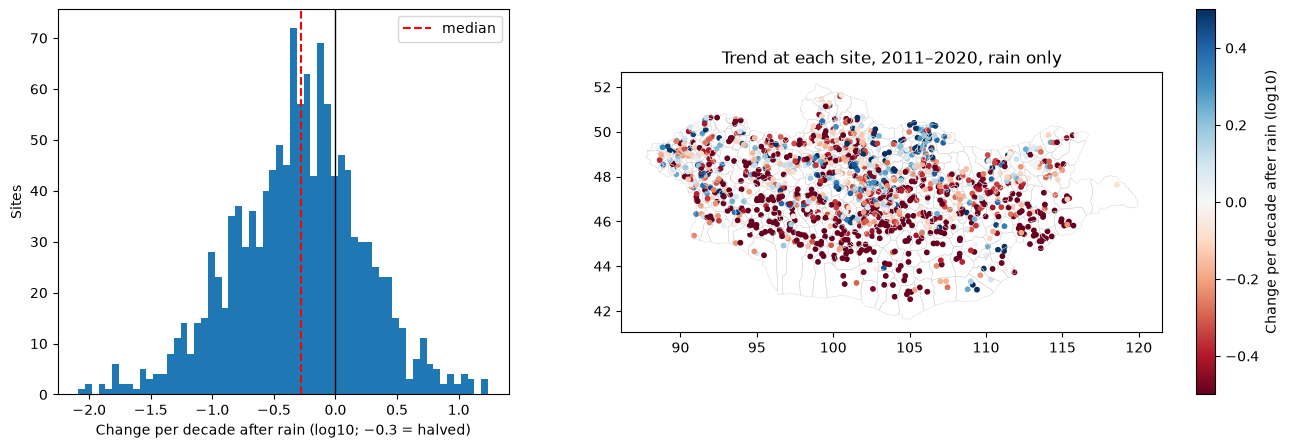

In [9]:
fig, (ax_hist, ax_map) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [2, 3]})

ax_hist.hist(rain_trends["decade"], bins=60)
ax_hist.axvline(0, color="black", linewidth=1)
ax_hist.axvline(rain_trends["decade"].median(), color="red", linestyle="--", label="median")
ax_hist.set_xlabel("Change per decade after rain (log10; −0.3 = halved)")
ax_hist.set_ylabel("Sites")
ax_hist.legend()

for outline in data.read_soum_outlines().values():
    ax_map.plot(*outline.exterior.xy, color="lightgrey", linewidth=0.3)
points = ax_map.scatter(rain_trends["lon"], rain_trends["lat"], c=rain_trends["decade"],
                        cmap="RdBu", vmin=-0.5, vmax=0.5, s=10)
ax_map.set_aspect(MAP_ASPECT)
fig.colorbar(points, ax=ax_map, label="Change per decade after rain (log10)")
ax_map.set_title("Trend at each site, 2011–2020, rain only")
plt.show()

At first sight most sites decline. With rain only, the median site loses 47% per decade, 73% of sites go down, and 284 have p < 0.05 where 62 would by chance. 46 remain after controlling the false discovery rate. With temperature, 20.5% of sites have p < 0.05.

Much of this is the shared pattern above, not site-by-site change, and single clippings are noisy. Notebook 3 measures what the method can detect before any site is called degrading. The map is therefore not read as a map of degradation.

## Save

In [10]:
remainders.to_csv(paths.PROCESSED_DIR / "remainders.csv", index=False)
site_trends.to_csv(paths.PROCESSED_DIR / "site_trends.csv", index=False)
print(f"Saved {len(remainders)} site-years to data/processed/remainders.csv")
print(f"Saved {len(site_trends)} site trends (two models) to data/processed/site_trends.csv")

Saved 13367 site-years to data/processed/remainders.csv
Saved 2500 site trends (two models) to data/processed/site_trends.csv
